In [36]:
"""
Importing sunpy and other packages
"""

from sunpy.net import Fido
from sunpy.net import attrs as a
from sunpy.timeseries import TimeSeries 
from sunpy.time import parse_time
from sunpy.data import cache
from sunpy.coordinates import spice, frames
from sunpy.coordinates import get_horizons_coord, get_body_heliographic_stonyhurst


from astropy import units as u
from astropy.time import Time


import matplotlib.pyplot as plt
import numpy as np 

# uncomment line below to see what datasets are available to query from the CDAWeb
a.cdaweb.Dataset.wi_k0_swe # WI_K0_SWE https://cdaweb.gsfc.nasa.gov/misc/NotesW.html#WI_K0_SWE

<sunpy.net.cdaweb.attrs.Dataset(WI_K0_SWE: Wind SWE (Solar Wind Experiment), Key Parameters [PRELIM]
- K. Ogilvie (NASA GSFC)) object at 0x16c0ee950>

In [37]:
# Cycle 23 
# 1 Dec 95 - 30 Nov 96 as Cycle 23 min
C23MinStart = parse_time("1995-12-01 00:00")
C23MinPartway = parse_time("1995-12-01 02:00")
# C23MinEnd = parse_time("1996-11-30 23:59")
# 1 Oct 99 - 30 Sept 00 as Cycle 23 max

# tstart = parse_time("2022-01-28 00:00")
# tend = parse_time("2022-01-30 14:00")

In [46]:
res_WIND = Fido.search(a.Time(C23MinStart, C23MinPartway), a.cdaweb.Dataset.wi_k0_swe)

In [39]:
res_WIND

Dataset,Start time,End time,URL
str9,str23,str23,str89
WI_K0_SWE,1995-12-01 00:00:02.000,1995-12-01 23:59:35.000,https://cdaweb.gsfc.nasa.gov/sp_phys/data/wind/swe/swe_k0/1995/wi_k0_swe_19951201_v02.cdf


In [40]:
files_WIND = Fido.fetch(res_WIND, path="./")

Files Downloaded: 100%|██████████| 1/1 [00:00<00:00,  3.18file/s]


In [51]:
files_WIND

['wi_k0_swe_19951201_v02.cdf']

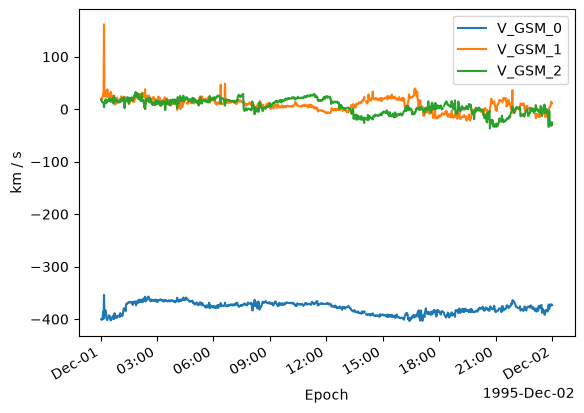

In [54]:
import warnings
warnings.filterwarnings("ignore")

WIND = TimeSeries(files_WIND, concatenate=True)

WIND.columns

fig, ax = plt.subplots()
WIND.plot(columns=["V_GSM_0", "V_GSM_1", "V_GSM_2"])

MagVsw = np.sqrt(WIND._data["V_GSM_0"]**2 + 
                               WIND._data["V_GSM_1"]**2 + 
                               WIND._data["V_GSM_2"]**2)
WIND = WIND.add_column("MagVsw", MagVsw)


In [ ]:
fig, ax  = plt.subplots(4, sharex=True, figsize=(10, 10))



# total wind speed
WIND._data["TotVsw"].plot(ax=ax[0], marker='.', ls='', ms=1)
ax[0].set_ylabel("Tot V$_{SW}$ (km/s)")
plt.axhline(400, ls="dashed")

# components of wind speed
WIND._data["V_GSM_0"].plot(ax=ax[0], marker='.', ls='', ms=1)
ax[0].set_ylabel("V_GSM_0 V$_{SW}$ (km/s)")
plt.axhline(400, ls="dashed")
# components of wind speed
WIND._data["V_GSM_1"].plot(ax=ax[0], marker='.', ls='', ms=1)
ax[0].set_ylabel("V_GSM_1 V$_{SW}$ (km/s)")
plt.axhline(400, ls="dashed")
# components of wind speed
WIND._data["V_GSM_1"].plot(ax=ax[0], marker='.', ls='', ms=1)
ax[0].set_ylabel("V_GSM_1 V$_{SW}$ (km/s)")
plt.axhline(400, ls="dashed")


for aa in ax:
    aa.legend(loc="upper left")
    aa.axvline("2022-01-29 00:00", color='k')
    aa.axvline("2022-01-30 02:00", color='k', ls="dashed")
    
ax[0].set_xlim(psp_spc.time[0].datetime, psp_spc.time[-1].datetime)
ax[4].set_xlabel("Time")
plt.tight_layout()
plt.subplots_adjust(hspace=0.02)

In [ ]:
)